Open split.pkl which contains the following test split on the cleaned tweets.txt and emoji.txt data: X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.2, random_state=42)

In [13]:
import pickle

with open('/content/drive/MyDrive/emoji_project/datasets/split_data/data_split.pkl', 'rb') as f:
    X_train, X_test, y_train, y_test = pickle.load(f)

Vectorize, or convert strings into numerical vectors, the data so that the machine learning algorithm can understand and analyze it.

In [ ]:
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer


with open('/content/drive/MyDrive/emoji_project/datasets/split_data/data_split.pkl', 'rb') as f:
    X_train, X_test, y_train, y_test = pickle.load(f)

vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

Create the Logistic Regression model and print get the classification report and confustion matrix.

In [17]:
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer


with open('/content/drive/MyDrive/emoji_project/datasets/split_data/data_split.pkl', 'rb') as f:
    X_train, X_test, y_train, y_test = pickle.load(f)

vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_tfidf, y_train)

preds = model.predict(X_test_tfidf)
print(classification_report(y_test, preds))
print(confusion_matrix(y_test, preds))

              precision    recall  f1-score   support

       blush       0.36      0.33      0.35      4568
     flushed       0.39      0.58      0.47      2067
        grin       0.40      0.38      0.39      2964
  heart_eyes       0.66      0.52      0.59      7919
     relaxed       0.28      0.39      0.33      2143
       smirk       0.33      0.46      0.39      3000
         sob       0.63      0.40      0.49      9989
       weary       0.40      0.46      0.43      5344
        wink       0.35      0.47      0.40      3679
         yum       0.42      0.53      0.47      3394

    accuracy                           0.45     45067
   macro avg       0.42      0.45      0.43     45067
weighted avg       0.48      0.45      0.45     45067

[[1524  146  276  320  471  402  302  270  553  304]
 [  95 1194   69   70   53   96  147  138  157   48]
 [ 257  143 1134  154  200  241  176  158  368  133]
 [ 376  231  253 4152  448  289  378  521  397  874]
 [ 296   50  111  164  844  1

Results:

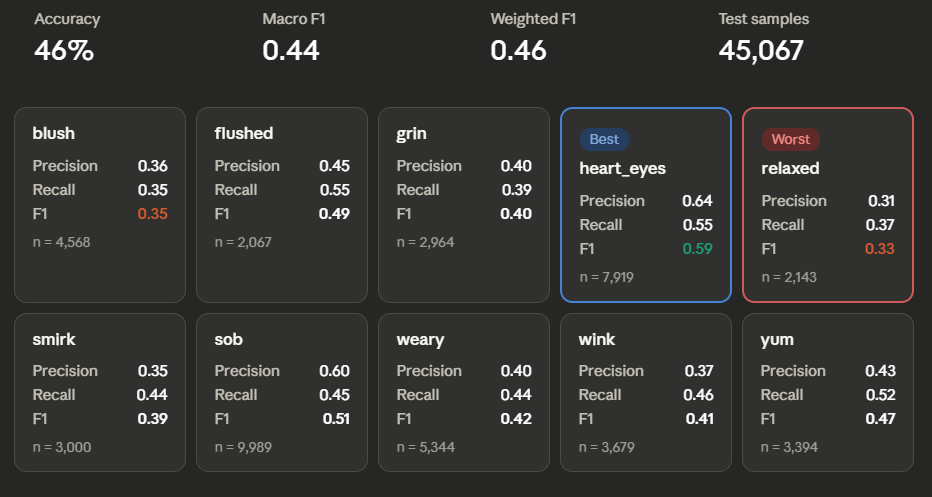

The overall accurary of the model is 46%, with the best class being heart_eyes and worst class is relaxed.

Our model does well with heart_eyes (F1 = 0.59, precision = 0.64), indicating that tweets with this emoji tend to contain strong, unambiguous positive language ("obsessed with", "in love with", "this is amazing") that TF-IDF can latch onto easily. The sob emoji also has high precision (0.60), meaning when it predicts sobbing it's usually right, though it misses almost half the true sob tweets (recall = 0.45).

However, our model struggles with relaxed (F1 = 0.33). Looking at the confusion matrix, true relaxed tweets are often incorrectly identified as blush, heart_eyes, and smirk. This suggests that the relaxed emoji appears in ambiguous, mild contexts making it difficult to differentiate from others. On the same note, the blush emoji is also weak (F1 = 0.35).

The results are visualized below.

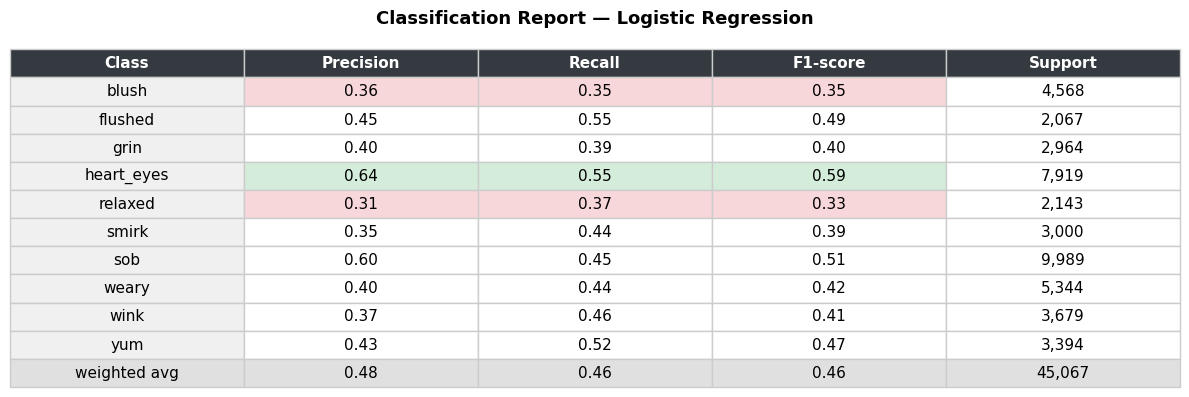

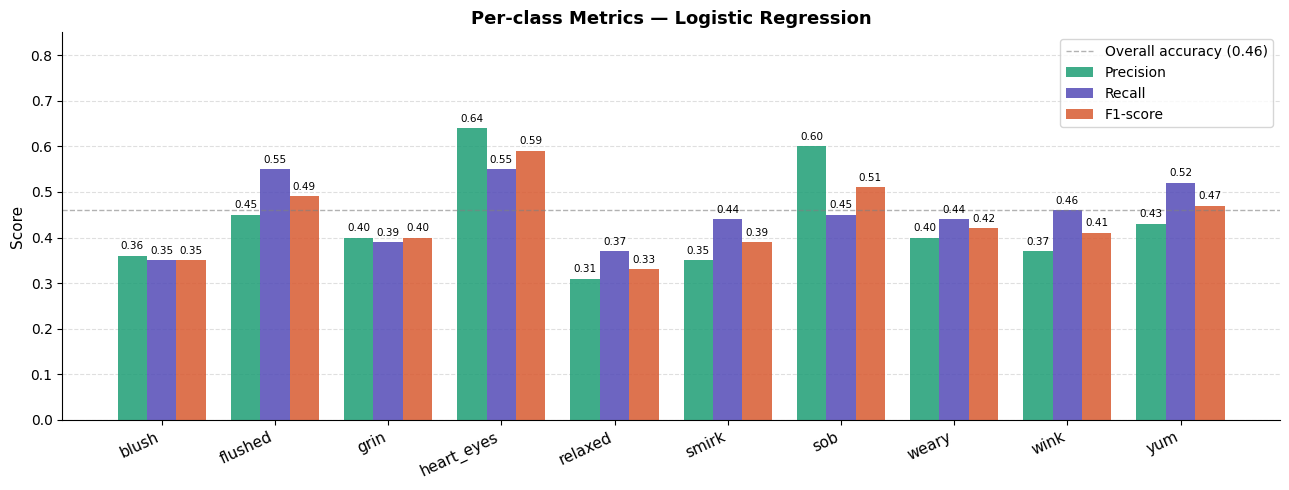

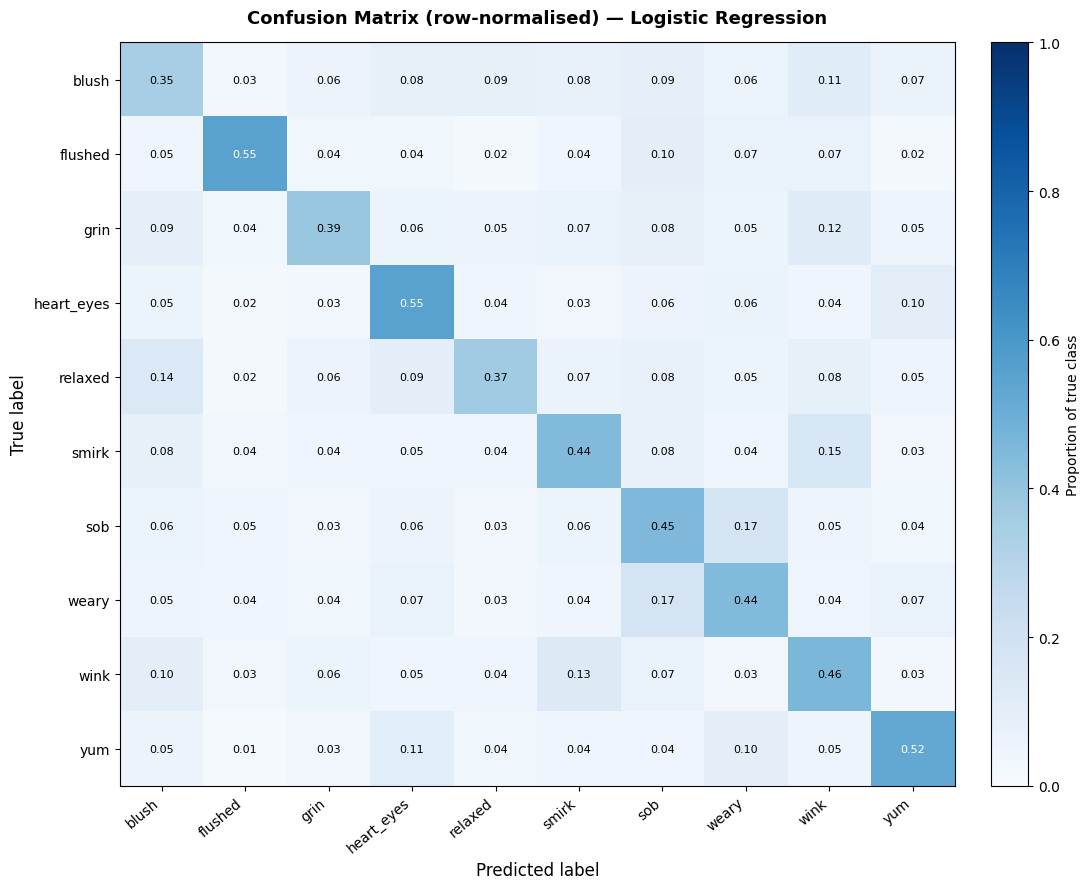

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

labels = ['blush','flushed','grin','heart_eyes','relaxed','smirk','sob','weary','wink','yum']
precision = [0.36, 0.45, 0.40, 0.64, 0.31, 0.35, 0.60, 0.40, 0.37, 0.43]
recall    = [0.35, 0.55, 0.39, 0.55, 0.37, 0.44, 0.45, 0.44, 0.46, 0.52]
f1        = [0.35, 0.49, 0.40, 0.59, 0.33, 0.39, 0.51, 0.42, 0.41, 0.47]
support   = [4568, 2067, 2964, 7919, 2143, 3000, 9989, 5344, 3679, 3394]

cm = np.array([
    [1581, 123, 256, 376, 389, 345, 404, 271, 520, 303],
    [  94,1144,  77,  80,  43,  92, 208, 141, 145,  43],
    [ 265, 115,1150, 183, 163, 206, 238, 155, 349, 140],
    [ 419, 175, 240,4366, 337, 265, 445, 499, 353, 820],
    [ 301,  41, 119, 203, 783, 140, 166, 109, 178, 103],
    [ 253, 105, 133, 139, 123,1333, 226, 128, 458, 102],
    [ 610, 459, 347, 580, 284, 606,4493,1748, 481, 381],
    [ 270, 239, 196, 364, 152, 235, 931,2359, 234, 364],
    [ 368, 119, 224, 169, 145, 482, 251, 128,1682, 111],
    [ 186,  45, 114, 368, 120, 145, 149, 327, 162,1778],
])

# ── Figure 1: Table ───────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(12, 4))
ax1.axis('off')

col_labels = ['Class', 'Precision', 'Recall', 'F1-score', 'Support']
rows = [[l, f'{p:.2f}', f'{r:.2f}', f'{f:.2f}', f'{s:,}']
        for l, p, r, f, s in zip(labels, precision, recall, f1, support)]
rows.append(['weighted avg', '0.48', '0.46', '0.46', '45,067'])

cell_colors = []
for row in rows[:-1]:
    f_val = float(row[3])
    if f_val >= 0.55:
        color = '#d4edda'
    elif f_val <= 0.36:
        color = '#f8d7da'
    else:
        color = '#ffffff'
    cell_colors.append(['#f0f0f0', color, color, color, '#ffffff'])
cell_colors.append(['#e0e0e0'] * 5)

table = ax1.table(
    cellText=rows,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    cellColours=cell_colors
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.6)
for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor('#cccccc')
    if r == 0:
        cell.set_facecolor('#343a40')
        cell.set_text_props(color='white', fontweight='bold')

fig1.suptitle('Classification Report — Logistic Regression', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('table.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: Grouped bar chart ───────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(13, 5))

x = np.arange(len(labels))
w = 0.26
bars_p = ax2.bar(x - w, precision, w, label='Precision', color='#1D9E75', alpha=0.85)
bars_r = ax2.bar(x,     recall,    w, label='Recall',    color='#534AB7', alpha=0.85)
bars_f = ax2.bar(x + w, f1,        w, label='F1-score',  color='#D85A30', alpha=0.85)

ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=25, ha='right', fontsize=11)
ax2.set_ylim(0, 0.85)
ax2.set_ylabel('Score', fontsize=11)
ax2.set_title('Per-class Metrics — Logistic Regression', fontsize=13, fontweight='bold')
ax2.axhline(0.46, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Overall accuracy (0.46)')
ax2.legend(fontsize=10)
ax2.spines[['top', 'right']].set_visible(False)
ax2.yaxis.grid(True, linestyle='--', alpha=0.4)
ax2.set_axisbelow(True)

for bar in [*bars_p, *bars_r, *bars_f]:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.savefig('bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 3: Confusion matrix heatmap ───────────────────────────
fig3, ax3 = plt.subplots(figsize=(11, 9))

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
im = ax3.imshow(cm_norm, cmap='Blues', aspect='auto', vmin=0, vmax=1)

ax3.set_xticks(range(len(labels)))
ax3.set_yticks(range(len(labels)))
ax3.set_xticklabels(labels, rotation=40, ha='right', fontsize=10)
ax3.set_yticklabels(labels, fontsize=10)
ax3.set_xlabel('Predicted label', fontsize=12)
ax3.set_ylabel('True label', fontsize=12)
ax3.set_title('Confusion Matrix (row-normalised) — Logistic Regression',
              fontsize=13, fontweight='bold', pad=14)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = cm_norm[i, j]
        color = 'white' if val > 0.5 else 'black'
        ax3.text(j, i, f'{val:.2f}', ha='center', va='center',
                 fontsize=8, color=color)

plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04, label='Proportion of true class')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()